# Análisis para la Retencion de Clientes
### 1. Introducción y Objetivo

In [ ]:
pip install numpy matplotlib seaborn openpyxl jupyter

In [5]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report



df = pd.read_csv("Telco-Customer-Churn.csv")

# Calcular KPIs
ingresos_totales = df['MonthlyCharges'].sum()
ingresos_perdidos = df[df['Churn'] == 'Yes']['MonthlyCharges'].sum()
porcentaje_perdida = (ingresos_perdidos / ingresos_totales) * 100


#KPIs Estrategicos
print(f"Ingresos Totales: ${ingresos_totales:,.2f}")
print(f"Ingresos Perdidos (Churn): ${ingresos_perdidos:,.2f}")
print(f"Representan el {porcentaje_perdida:.2f}% del ingreso mensual.")
df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100


Ingresos Totales: $456,116.60
Ingresos Perdidos (Churn): $139,130.85
Representan el 30.50% del ingreso mensual.


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### 2. EDA Estrategico

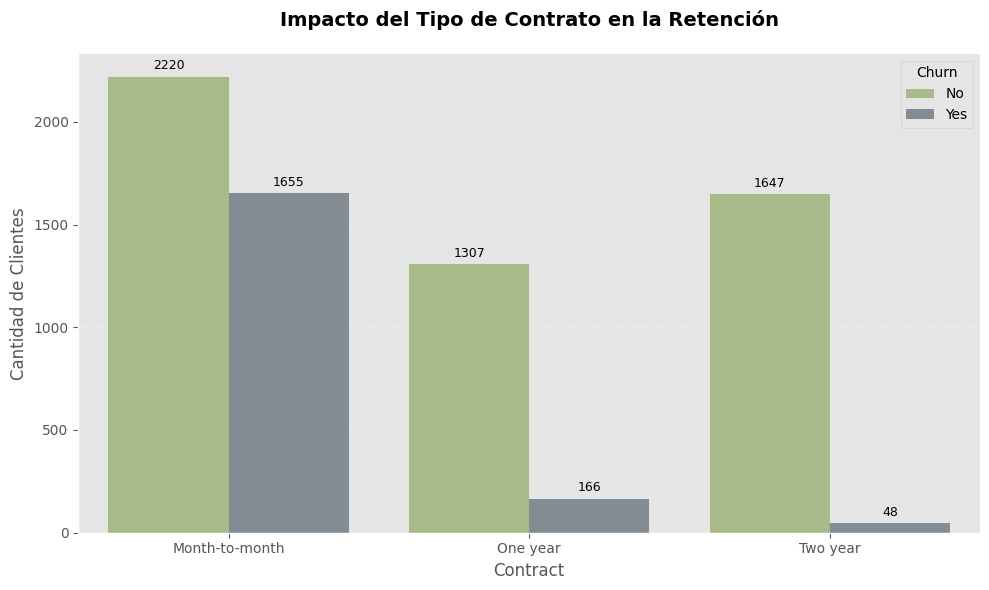

C:\Users\Liss\AppData\Local\Temp\ipykernel_27024\2149363728.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=x_col, data=df, palette=PALETA_ESTRATEGICA, ax=ax)


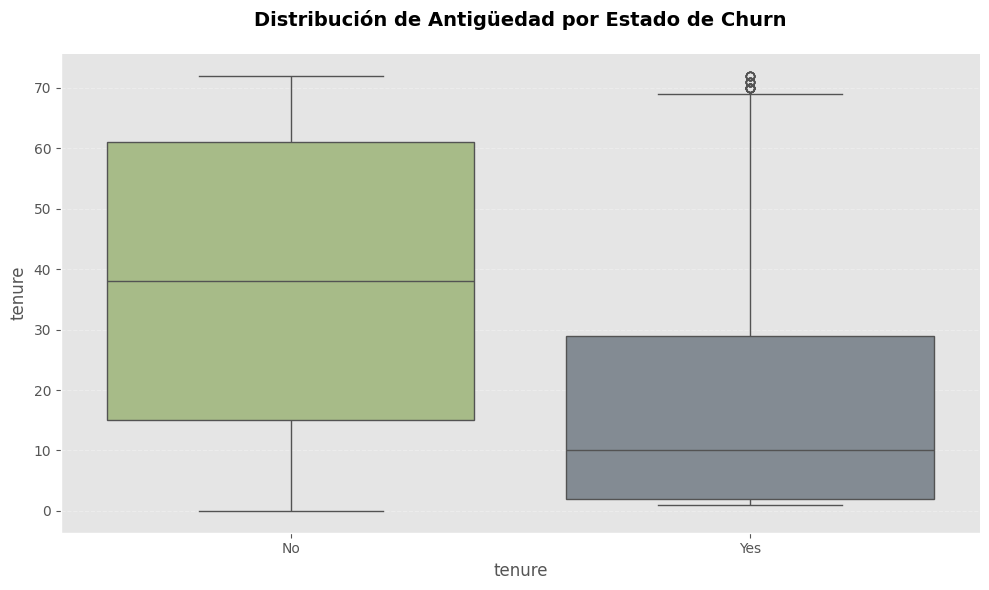

C:\Users\Liss\AppData\Local\Temp\ipykernel_27024\2149363728.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y=x_col, data=df, palette=PALETA_ESTRATEGICA, ax=ax)


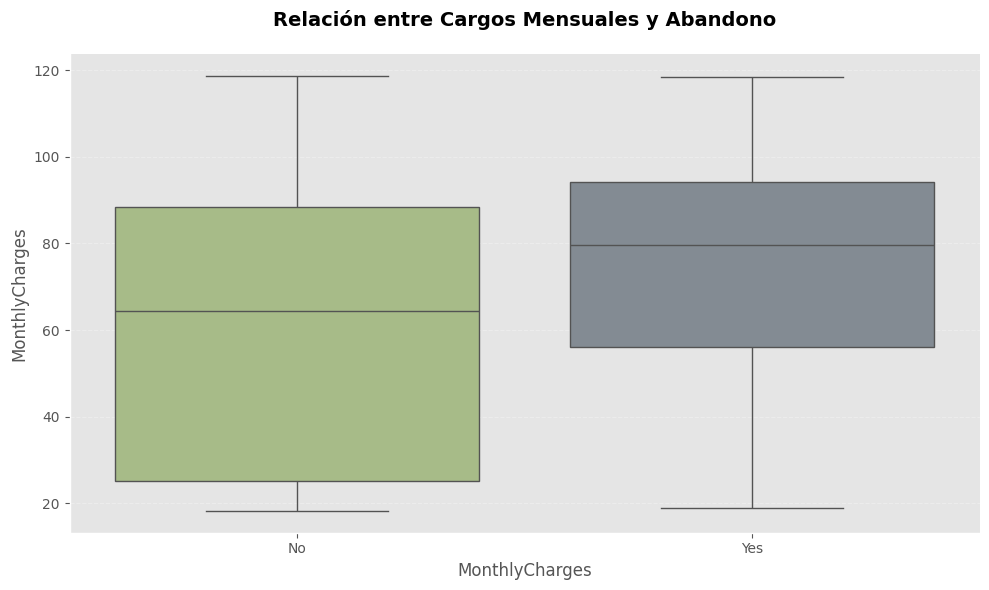

In [6]:
# Funcion para graficar el análisis de abandono
PALETA_ESTRATEGICA = ["#A9C47F", "#808B96"] 

def plot_churn_analysis(x_col, title, is_categorical=True):
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    
    if is_categorical:
        # Gráfico de barras comparativo
        sns.countplot(x=x_col, hue="Churn", data=df, palette=PALETA_ESTRATEGICA, ax=ax)
        ax.set_ylabel('Cantidad de Clientes')
        
        # Agregamos etiquetas de datos sobre las barras
        for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)
    else:
        # Gráfico de cajas (Boxplot) para variables numéricas (Tenure, Charges)
        sns.boxplot(x="Churn", y=x_col, data=df, palette=PALETA_ESTRATEGICA, ax=ax)
        ax.set_ylabel(x_col.replace('_', ' '))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(x_col.replace('_', ' '))
    
    plt.xticks(rotation=0 if is_categorical else 0)
    plt.tight_layout()
    plt.show()

# --- Aplicando la función a tus datos ---

# 1. Abandono vs Tipo de contrato (Categórico)
plot_churn_analysis('Contract', 'Impacto del Tipo de Contrato en la Retención')

# 2. Abandono vs Permanencia (Numérico)
plot_churn_analysis('tenure', 'Distribución de Antigüedad por Estado de Churn', is_categorical=False)

# 3. Abandono vs Cargos mensuales (Numérico)
plot_churn_analysis('MonthlyCharges', 'Relación entre Cargos Mensuales y Abandono', is_categorical=False)

**Hallazgos Clave:**

*Vulnerabilidad Contractual: El gráfico de barras revela que el abandono está masivamente concentrado en los contratos "Month-to-month" (mes a mes). En contraste, los contratos de uno y dos años muestran una retención excepcionalmente alta, con una pérdida de clientes mínima.*

*El Factor Antigüedad (Tenure): Existe una diferencia drástica en la permanencia. Los clientes que abandonan el servicio suelen hacerlo en una etapa temprana, con una mediana de antigüedad de apenas 10 meses, mientras que el grupo leal se mantiene estable con una mediana cercana a los 40 meses.*

*Impacto de la Tarifa Mensual: El análisis de cargos mensuales indica que los clientes con facturas más elevadas (mediana cercana a $80) tienen una mayor tendencia al abandono en comparación con los clientes que permanecen, quienes mantienen una mediana de cargos más baja (aprox. $65).*

### 3. Modelo de Regresion Logistica para predecir el abandono

In [7]:
# Preparación de datos para modelado predictivo
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df_model = df.drop("customerID", axis=1)
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop("Churn_Yes", axis=1) 
y = df_model["Churn_Yes"]

# Escalado de variables: Vital para que la Regresión Logística no priorice  variables con números grandes (como TotalCharges) sobre las pequeñas.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
) 

print(f"Modelo preparado con {X_train.shape[1]} variables predictoras.")

Modelo preparado con 30 variables predictoras.


In [8]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

# Uso de Random Forest: Elegido por su capacidad para capturar relaciones no lineales y darnos la 'Importancia de Variables'
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7874911158493249
Recall: 0.516042780748663
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



**Hallazgos Clave:**

*Poder Predictivo: El modelo alcanza un Accuracy del 79%, logrando identificar correctamente a la mayoría de los clientes con tendencia al abandono.*

*Sensibilidad (Recall): Detectamos al 52% de los desertores reales. Aunque es un buen inicio, existe una oportunidad de optimizar el modelo para capturar a ese 48% restante mediante técnicas de balanceo de datos.*

*Segmentación de Riesgo: Gracias a la probabilidad de Churn, hemos categorizado a los clientes en niveles (Bajo, Medio, Alto). Esto permite al equipo de Marketing no saturar a toda la base, sino actuar solo sobre el segmento de "Alto Riesgo".*

## 6. Recomendaciones Ejecutivas

Basado en este análisis estratégico, se realizan las siguientes recomendaciones gerenciales:

1. **Intervención de Alto Riesgo:** Implementar una regla de negocio automatizada donde cada cliente que el modelo clasifique con una probabilidad de abandono > 0.6 reciba una oferta de lealtad inmediata.
2. **Conversión de Contratos:** Dado que el tipo de contrato es un predictor clave, ofrecer incentivos para migrar a los clientes de "Mes a mes" (identificados por el modelo como los más volátiles) hacia planes anuales.
3. **Monitoreo de Cargos:** Establecer alertas de retención para clientes cuyos cargos mensuales superen la mediana de $80, ya que el modelo los identifica como el segmento de mayor sensibilidad y probabilidad de fuga.
